# Run

This notebook creates the neighbourhood aggregates from the preprocessed data.

## Settings

In [93]:
dist_folder = '../../tmp/data' # stores outputs
data_sources_file = 'data.csv'
study_area_dataset = 'toronto' # bbox will be used as study area
force = False # whether to force processing
genstats = ['sum', 'mean', 'min', 'max', 'median', 'var', 'skew', 'std', 'sem', 'mad'] # name of gen stats from pandas to agg numeric values
genstats_quantiles = True # whether to include quantiles in gen stats or not
grid_sizes = [10, 40, 80]

## Libraries

In [94]:
# Silence future warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Import libraries
import pandas as pd
import geopandas as gpd
import numpy as np
import re

# Import modules
from datetime import datetime, timedelta
from IPython.display import display, HTML
from numbers import Number
from pandas.api.types import is_numeric_dtype
from pathlib import Path
from shapely.geometry import box, Point
from time import time

## Classes

In [95]:
# For timing processes and displaying processing messages
class Timer:
    
    def __init__(self, name, process_name=None, start_prefix=None, end_prefix=None):
        self.name = name
        self.process_name = process_name
        self.start_prefix = start_prefix if start_prefix else 'Loading' if process_name.startswith('already') else 'Processing'
        self.end_prefix = end_prefix if end_prefix else 'Loaded' if process_name.startswith('already') else 'Processed'
    
    def start(self):
        self.start = time()
        self.start_dt = datetime.now()
        print(f'{self.start_prefix} {self.name} - {self.process_name} ({self.start_dt})...')
    
    def end(self):
        self.end = time()
        self.end_dt = datetime.now()
        self.elapsed = str(timedelta(seconds=self.end - self.start))
        print(f'{self.end_prefix} {self.name} - {self.process_name} ({self.end_dt}) [Elapsed: {self.elapsed}]')

## Functions

### Data Functions

In [96]:
# Formats human readable sizes in bytes
# https://stackoverflow.com/questions/1094841/get-human-readable-version-of-file-size
def format_size(num, suffix="B"):
    for unit in ["", "Ki", "Mi", "Gi", "Ti", "Pi", "Ei", "Zi"]:
        if abs(num) < 1024.0:
            return f"{num:3.1f} {unit}{suffix}"
        num /= 1024.0
    return f"{num:.1f} Yi{suffix}"

# Format cols to be lowercase with underscores and alphanumerics only
def format_cols(df):
    out = df
    out = out.rename(str.lower, axis='columns') # lowercase
    out.columns = [re.sub('[^A-Za-z0-9 ]+', '', c) for c in out.columns] # remove non alphanumeric
    out.columns = [' '.join(c.split()).replace(' ', '_') for c in out.columns] # remove extra whitespace, replace w/ underscore
    return out

# Extracts file info for summary
def file_info(file):
    stats = Path(file).stat()
    modified = datetime.fromtimestamp(stats.st_mtime)
    created = datetime.fromtimestamp(stats.st_birthtime)
    size = format_size(stats.st_size)
    out = {'created': created, 'modified': modified, 'size': size}
    return out

# Get basic info on a pandas dataframe
def df_info(df, name):
    memory = format_size(df.memory_usage().sum())
    cols = len(df.columns)
    rows = len(df)
    geometry = str(pd.unique(df.geometry.geom_type)) if 'geometry' in df else None
    out = {
        'dataset': name,
        'columns': cols,
        'rows': rows,
        'memory_usage': memory,
        'geometry': geometry
    }
    return out

# Read csv, shp, or geojson file into pandas or geopandas
def read_data(file, *args, **kwargs):
    path = Path(file)
    ext = path.suffix if path.suffix != '.zip' else path.suffixes[0]
    ext = ext.lower()
    if ext == '.csv':
        out = pd.read_csv(file, *args, **kwargs)
    elif ext in ['.geojson', '.shp']:
        out = gpd.read_file(file, *args, **kwargs)
    else:
        raise ValueError('File format not supported')
    return out

# Read processed dataset in dist folder
def read_clean_dataset(dataset, folder='../dist', *args, **kwargs):
    file = Path(f'{folder}/clean-datasets/{dataset}.geojson')
    out = read_data(file, *args, **kwargs)
    return out

# Check if dataset is processed in dist folder
def dataset_processed(dataset, folder='../dist'):
    file = Path(f'{folder}/clean-datasets/{dataset}.geojson')
    out = file.is_file()
    return out

# Save variable to csv files
def save_vars(gdf, size, dist_folder=dist_folder):
    for c in gdf.columns:
        if c != 'geometry':
            v = gdf[c]
            v.to_csv(f'{dist_folder}/by-variable-{size}/{c}.csv')

### Grid Function

In [97]:
# Generate geogrids using a bounding box
# Edited from James Brennan's code
# https://james-brennan.github.io/posts/fast_gridding_geopandas/
def gen_grid(bbox, size=100):
    
    # Get bounds of bbox
    xmin, ymin, xmax, ymax = bbox.total_bounds
    crs = bbox.crs
    
    # Calculate cell size based on num of cells
    cell_size = (xmax-xmin)/size
    
    # Generate cells
    grid_cells = []
    for x0 in np.arange(xmin, xmax+cell_size, cell_size):
        for y0 in np.arange(ymin, ymax+cell_size, cell_size):
            x1 = x0-cell_size
            y1 = y0+cell_size
            grid_cells.append(box(x0, y0, x1, y1))
    
    # Create geodf and return
    out = gpd.GeoDataFrame(
        grid_cells,
        columns=['geometry'],
        crs=crs
    )
    out.index = list(out.index)
    return out

### Aggregation Functions

In [98]:
# Calculates the mode for a series
def mode(x):
    out = x.map(str).value_counts().index[0]
    return out

# 25 per quantile
def quantile25(df):
    out = df.quantile(0.25)
    return out

# 50 per quantile
def quantile50(df):
    out = df.quantile(0.5)
    return out

# 75 per quantile
def quantile75(df):
    out = df.quantile(0.75)
    return out

# Return a func for getting geom length aggs
def glen(agg):
    def out(x):
        return getattr(x.length, agg)()
    return out

# Calculates the counts of unique values given all possible values
def ucounts(df, c, possible, round=False):
    
    # Get counts in df
    counts = df[c].value_counts().to_dict()
    
    # Round numeric values
    if round:
        possible = [int(k) if isinstance(k, Number) else k for k in possible]
        counts = {int(k) if isinstance(k, Number) else k: v for k,v in counts.items()}
    
    # Apply counts as dict with possible values
    possible = [str(k) for k in possible]
    out = {k:[0] for k in possible}
    for k, v in counts.items():
        out[str(k)] = [v]
    out = pd.DataFrame(out)
    return out

### Metric Functions

In [99]:
# Calculate line sinuosity (how curved lines are)
def lsin(geom):
    
    # Calculate straight length
    start = gpd.GeoSeries([Point(g.coords[0]) for g in geom])
    end = gpd.GeoSeries([Point(g.coords[-1]) for g in geom])
    straight_len = start.distance(end).reset_index(drop=True)
    
    # Calculate sin = actual / straight
    actual_len = geom.length.reset_index(drop=True)
    out = actual_len / straight_len
    return out

## Run

Create folders to store processed data:

In [100]:
# Create folders for clean and output data
Path(dist_folder).mkdir(parents=True, exist_ok=True)
Path(f'{dist_folder}/base-grids').mkdir(parents=True, exist_ok=True)
for size in grid_sizes:
    for f in [f'by-dataset-{size}', f'by-variable-{size}']:
        Path(f'{dist_folder}/{f}').mkdir(parents=True, exist_ok=True)

Read the study area dataset:

In [101]:
study_area = read_data(f'{dist_folder}/clean-datasets/{study_area_dataset}.geojson')

Track processing time for all datasets and procedures:

In [102]:
gtimer = Timer('all datasets', 'preprocessing')
gtimer.start()

Processing all datasets - preprocessing (2025-01-20 18:49:26.687845)...


Include quantiles in general statistics for aggregating numeric values during spatial binning:

In [103]:
if genstats_quantiles:
    genstats = genstats + [quantile25, quantile50, quantile75]

### Grid Creation

Create grids of various sizes for binning.

In [104]:
allgrids = {}
for size in grid_sizes:
    file = Path(f'{dist_folder}/base-grids/geogrid_to_{size}_base.geojson')
    if not file.is_file() or force:
        grid = gen_grid(study_area, size)
        grid.to_file(file)
        allgrids[str(size)] = grid
    else:
        allgrids[str(size)] = read_data(file)

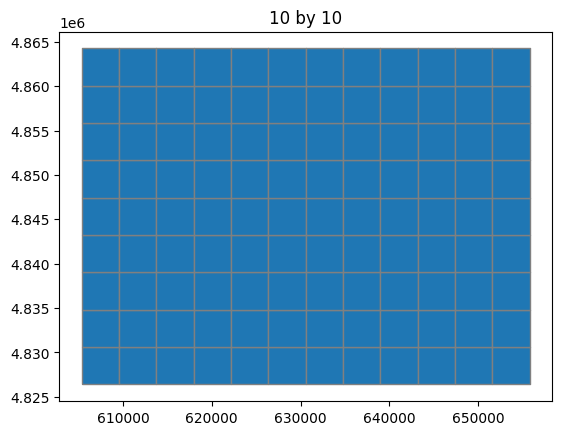

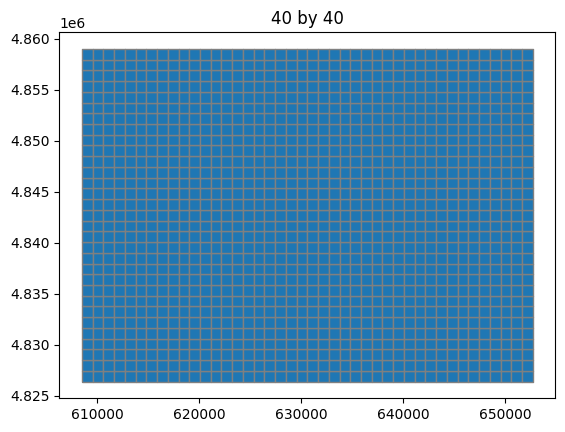

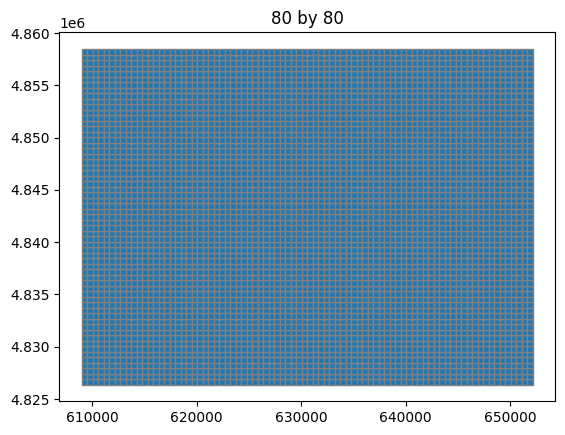

In [105]:
for size in allgrids:
    allgrids[size].plot(edgecolor='gray').set_title(f'{size} by {size}')

### Spatial Binning (Counts Only)

Spatially bin counted column values into each neighbourhood using the cleaned datasets.

In [106]:
to_count = [
    'autospeed_enforcement',
    'red_light_cams',
    'police',
    'ambulance',
    'fire_hydrants',
    'fire_stations',
    'renewables',
    'bicycle_parking',
    'transit_shelters',
    'wayfind',
    'litter',
    'art',
    'culture',
    'religious'
]
for size, grid in allgrids.items():
    
    for name in to_count:

        # Read data
        data = read_data(f'{dist_folder}/clean-datasets/{name}.geojson')

        # Only process if dataset file not created
        file = Path(f'{dist_folder}/by-dataset-{size}/geogrid_to_{name}.geojson')
        if not file.is_file() or force:

            # Start processing
            timer = Timer(f'{name} ({size})', 'spatial binning')
            timer.start()

            # Spatial join to grid
            join = grid.sjoin(data, predicate='intersects')

            # Agg counts
            counts = join.groupby(join.index).size()
            counts_col = f'{name}_count'
            counts.name = counts_col

            # Add counts to grid
            gdf = grid.join(counts)
            gdf[counts_col] = gdf[counts_col].fillna(0)

            # Save by dataset
            gdf.to_file(file)

            # Save by variable
            save_vars(gdf, size)

            # End processing
            timer.end()

        else:
            print(f'Skipping {file} - already binned ({datetime.now()})')

Skipping ../../tmp/data/by-dataset-10/geogrid_to_autospeed_enforcement.geojson - already binned (2025-01-20 18:49:28.234439)
Skipping ../../tmp/data/by-dataset-10/geogrid_to_red_light_cams.geojson - already binned (2025-01-20 18:49:28.257622)
Skipping ../../tmp/data/by-dataset-10/geogrid_to_police.geojson - already binned (2025-01-20 18:49:28.263176)
Skipping ../../tmp/data/by-dataset-10/geogrid_to_ambulance.geojson - already binned (2025-01-20 18:49:28.269885)
Skipping ../../tmp/data/by-dataset-10/geogrid_to_fire_hydrants.geojson - already binned (2025-01-20 18:49:31.283967)
Skipping ../../tmp/data/by-dataset-10/geogrid_to_fire_stations.geojson - already binned (2025-01-20 18:49:31.305883)
Skipping ../../tmp/data/by-dataset-10/geogrid_to_renewables.geojson - already binned (2025-01-20 18:49:31.319319)
Skipping ../../tmp/data/by-dataset-10/geogrid_to_bicycle_parking.geojson - already binned (2025-01-20 18:49:32.617537)
Skipping ../../tmp/data/by-dataset-10/geogrid_to_transit_shelters.g

### Spatial Binning (Aggregates)

Spatially bin aggregate column values into each neighbourhood using the cleaned datasets.

#### centrelines

Bin centreline geometry calculations and features:

In [107]:
name = 'centrelines'
data = read_data(f'{dist_folder}/clean-datasets/{name}.geojson')

for size, grid in allgrids.items():
    
    # Only process if dataset file not created
    file = Path(f'{dist_folder}/by-dataset-{size}/geogrid_to_{name}.geojson')
    if not file.is_file() or force:

        # Start processing
        timer = Timer(f'{name} ({size})', 'spatial binning')
        timer.start()

        # Split lines at polygons using overlay
        overlay = gpd.overlay(
            data,
            grid,
            how='intersection'
        ).explode(index_parts=False)

        # Add sinuosity metric (how curved lines are)
        overlay.insert(
            len(overlay.columns) - 2, # insert before geometry
            'sin',
            lsin(overlay.geometry)
        )

        # Spatial join lines to each grid
        join = overlay.sjoin(grid, predicate='intersects')

        # Aggregate cols by grid
        group = join.groupby(join['index_right'])
        agg = group.agg({
            'centrelines_feature_code': [mode],
            'centrelines_oneway_dir_code': [mode],
            'geometry': [
                ('len_sum', glen('sum')),
                ('len_mean', glen('mean')),
                ('len_median', glen('median')),
                ('len_min', glen('min')),
                ('len_max', glen('max'))
            ],
            'sin': genstats
        })

        # Rename agg cols
        agg.columns = ['_'.join(c).strip().replace('geometry_', '') for c in agg.columns]
        agg.columns = [f'{name}_{c}' if not c.startswith(f'{name}_') else c for c in agg.columns]

        # Count freq
        freq = []
        for c in ['centrelines_feature_code', 'centrelines_oneway_dir_code']:

            # Get possible unique values in col
            possible = data[c].unique()

            # Count freq for each unique value
            f = group.apply(ucounts, c=c, possible=possible)

            # Rename freq cols
            f = format_cols(f)
            prefix = c.replace(f'{name}_', '')
            f.columns = [f'{name}_{prefix}_{c}_count' for c in f.columns]
            freq.append(f)

        # Combine count freq
        freq = pd.concat(freq, axis=1)
        freq.index = freq.index.get_level_values(0)

        # Add agg and freq to grid
        gdf = grid.join(agg)
        gdf = gdf.join(freq)

        # Save by dataset
        gdf.to_file(file)

        # Save by variable
        save_vars(gdf, size)

        # End processing
        timer.end()

    else:
        print(f'Skipping {file} - already binned ({datetime.now()})')

Skipping ../../tmp/data/by-dataset-10/geogrid_to_centrelines.geojson - already binned (2025-01-20 18:49:52.294776)
Skipping ../../tmp/data/by-dataset-40/geogrid_to_centrelines.geojson - already binned (2025-01-20 18:49:52.295079)
Skipping ../../tmp/data/by-dataset-80/geogrid_to_centrelines.geojson - already binned (2025-01-20 18:49:52.295111)


#### collisions

Bin collision features and counts:

In [108]:
name = 'collisions'
data = read_data(f'{dist_folder}/clean-datasets/{name}.geojson')

for size, grid in allgrids.items():
    
    # Only process if dataset file not created
    file = Path(f'{dist_folder}/by-dataset-{size}/geogrid_to_{name}.geojson')
    if not file.is_file() or force:

        # Start processing
        timer = Timer(f'{name} ({size})', 'spatial binning')
        timer.start()

        # Convert objects to numeric
        for c in ['collisions_occ_year', 'collisions_occ_hour']:
            data[c] = pd.to_numeric(data[c]) 

        # Spatial join to grid
        join = grid.sjoin(data, predicate='intersects')

        # Agg cols by grid
        group = join.groupby(join.index)
        dtstats = [s for s in genstats if s != 'sum']
        agg = group.agg({
            'collisions_occ_month': [mode],
            'collisions_occ_dom': [mode] + dtstats,
            'collisions_occ_dow': [mode],
            'collisions_occ_year': [mode] + dtstats,
            'collisions_occ_hour': [mode] + dtstats,
            'collisions_fatalities': genstats,
            'collisions_injury': genstats,
            'collisions_ftr': genstats,
            'collisions_pd': genstats,
        })

        # Rename agg cols
        agg.columns = ['_'.join(c).strip() for c in agg.columns]

        # Count freq
        freq = []
        for c in ['collisions_occ_month', 'collisions_occ_dom', 'collisions_occ_dow', 'collisions_occ_year', 'collisions_occ_hour']:

            # Get possible unique values in col
            round = False
            if c == 'collisions_occ_month':
                possible = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
            elif c == 'collisions_occ_dom':
                possible = [*range(1,32)]
                round = True
            elif c == 'collisions_occ_dow':
                possible = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
            elif c == 'collisions_occ_hour':
                possible = [*range(0,24)]
                round = True
            else:
                possible = data[c].unique()

            # Count freq for each unique value
            f = group.apply(ucounts, c=c, possible=possible, round=round)

            # Rename freq cols
            f = format_cols(f)
            prefix = c.replace(f'{name}_', '')
            f.columns = [f'{name}_{prefix}_{c}_count' for c in f.columns]
            freq.append(f)

        # Combine count freq
        freq = pd.concat(freq, axis=1)
        freq.index = freq.index.get_level_values(0)

        # Agg counts
        counts = group.size()
        counts.name = f'{name}_count'

        # Add agg, freq, and counts to grid
        gdf = grid.join(agg)
        gdf = gdf.join(freq)
        gdf = gdf.join(counts)
        gdf[f'{name}_count'] = gdf[f'{name}_count'].fillna(0)

        # Save by dataset
        gdf.to_file(file)

        # Save by variable
        save_vars(gdf, size)

        # End processing
        timer.end()

    else:
        print(f'Skipping {file} - already binned ({datetime.now()})')

Skipping ../../tmp/data/by-dataset-10/geogrid_to_collisions.geojson - already binned (2025-01-20 18:50:57.807595)
Skipping ../../tmp/data/by-dataset-40/geogrid_to_collisions.geojson - already binned (2025-01-20 18:50:57.808520)
Skipping ../../tmp/data/by-dataset-80/geogrid_to_collisions.geojson - already binned (2025-01-20 18:50:57.808568)


#### traffic

Bin counts of traffic features and counts:

In [109]:
name = 'traffic'
data = read_data(f'{dist_folder}/clean-datasets/{name}.geojson')

for size, grid in allgrids.items():

    # Only process if dataset file not created
    file = Path(f'{dist_folder}/by-dataset-{size}/geogrid_to_{name}.geojson')
    if not file.is_file() or force:

        # Start processing
        timer = Timer(f'{name} ({size})', 'spatial binning')
        timer.start()

        # Spatial join to grid
        join = grid.sjoin(data, predicate='intersects')

        # Agg cols by grid
        group = join.groupby(join.index)
        agg = group.agg({
            c: genstats for c in data.columns if c not in ['geometry', 'traffic_month', 'traffic_day_of_month', 'traffic_year']
        })

        # Rename agg cols
        agg.columns = ['_'.join(c).strip() for c in agg.columns]

        # Count freq
        freq = []
        for c in ['traffic_month', 'traffic_day_of_month', 'traffic_year']:

            # Get possible unique values in col
            if c == 'traffic_month':
                possible = [*range(1,32)]
            elif c == 'traffic_day_of_month':
                possible = [*range(1,32)]
            else:
                possible = data[c].unique()

            # Count freq for each unique value
            f = group.apply(ucounts, c=c, possible=possible)

            # Rename freq cols
            f = format_cols(f)
            prefix = c.replace(f'{name}_', '')
            f.columns = [f'{name}_{prefix}_{c}_count' for c in f.columns]
            freq.append(f)

        # Combine count freq
        freq = pd.concat(freq, axis=1)
        freq.index = freq.index.get_level_values(0)

        # Agg counts
        counts = group.size()
        counts.name = f'{name}_count'

        # Add agg, freq, and counts to grid
        gdf = grid.join(agg)
        gdf = gdf.join(freq)
        gdf = gdf.join(counts)
        gdf[f'{name}_count'] = gdf[f'{name}_count'].fillna(0)

        # Save by dataset
        gdf.to_file(file)

        # Save by variable
        save_vars(gdf, size)

        # End processing
        timer.end()

    else:
        print(f'Skipping {file} - already binned ({datetime.now()})')

#### watch_your_speed

Bin watch your speed program location counts and features:

In [ ]:
name = 'watch_your_speed'
data = read_data(f'{dist_folder}/clean-datasets/{name}.geojson')

for size, grid in allgrids.items():
    
    # Only process if dataset file not created
    file = Path(f'{dist_folder}/by-dataset-{size}/geogrid_to_{name}.geojson')
    if not file.is_file() or force:

        # Start processing
        timer = Timer(f'{name} ({size})', 'spatial binning')
        timer.start()

        # Convert objects to numeric
        for c in ['wys_min_speed', 'wys_speed_limit']:
            data[c] = pd.to_numeric(data[c]) 

        # Spatial join to grid
        join = grid.sjoin(data, predicate='intersects')

        # Agg cols by grid
        group = join.groupby(join.index)
        agg = group.agg({
            'wys_dir': [mode],
            'wys_min_speed': [mode] + genstats,
            'wys_speed_limit': [mode] + genstats,
        })

        # Rename agg cols
        agg.columns = ['_'.join(c).strip() for c in agg.columns]

        # Count freq
        freq = []
        for c in ['wys_dir', 'wys_min_speed', 'wys_speed_limit']:

            # Get possible unique values in col
            possible = data[c].unique()

            # Count freq for each unique value
            f = group.apply(ucounts, c=c, possible=possible)

            # Rename freq cols
            f = format_cols(f)
            prefix = c.replace(f'wys_', '')
            f.columns = [f'wys_{prefix}_{c}_count' for c in f.columns]
            freq.append(f)

        # Combine count freq
        freq = pd.concat(freq, axis=1)
        freq.index = freq.index.get_level_values(0)

        # Agg counts
        counts = group.size()
        counts.name = 'wys_count'

        # Add agg, freq, and counts to grid
        gdf = grid.join(agg)
        gdf = gdf.join(freq)
        gdf = gdf.join(counts)
        gdf['wys_count'] = gdf['wys_count'].fillna(0)

        # Save by dataset
        gdf.to_file(file)

        # Save by variable
        save_vars(gdf, size)

        # End processing
        timer.end()

    else:
        print(f'Skipping {file} - already binned ({datetime.now()})')

#### schools

Bin school location counts and features:

In [ ]:
name = 'schools'
data = read_data(f'{dist_folder}/clean-datasets/{name}.geojson')

for size, grid in allgrids.items():
    
    # Only process if dataset file not created
    file = Path(f'{dist_folder}/by-dataset-{size}/geogrid_to_{name}.geojson')
    if not file.is_file() or force:

        # Start processing
        timer = Timer(f'{name} ({size})', 'spatial binning')
        timer.start()

        # Spatial join to grid
        join = grid.sjoin(data, predicate='intersects')

        # Agg cols by grid
        group = join.groupby(join.index)
        agg = group.agg({
            'schools_level': [mode],
            'schools_type': [mode]
        })

        # Rename agg cols
        agg.columns = ['_'.join(c).strip() for c in agg.columns]

        # Count freq
        freq = []
        for c in ['schools_level', 'schools_type']:

            # Get possible unique values in col
            possible = data[c].unique()

            # Count freq for each unique value
            f = group.apply(ucounts, c=c, possible=possible)

            # Rename freq cols
            f = format_cols(f)
            prefix = c.replace(f'{name}_', '')
            f.columns = [f'{name}_{prefix}_{c}_count' for c in f.columns]
            freq.append(f)

        # Combine count freq
        freq = pd.concat(freq, axis=1)
        freq.index = freq.index.get_level_values(0)

        # Agg counts
        counts = group.size()
        counts.name = f'{name}_count'

        # Add agg, freq, and counts to grid
        gdf = grid.join(agg)
        gdf = gdf.join(freq)
        gdf = gdf.join(counts)
        gdf[f'{name}_count'] = gdf[f'{name}_count'].fillna(0)

        # Save by dataset
        gdf.to_file(file)

        # Save by variable
        save_vars(gdf, size)

        # End processing
        timer.end()

    else:
        print(f'Skipping {file} - already binned ({datetime.now()})')

#### childcare

Bin childcare location counts and features:

In [ ]:
name = 'childcare'
data = read_data(f'{dist_folder}/clean-datasets/{name}.geojson')

for size, grid in allgrids.items():
    
    # Only process if dataset file not created
    file = Path(f'{dist_folder}/by-dataset-{size}/geogrid_to_{name}.geojson')
    if not file.is_file() or force:

        # Start processing
        timer = Timer(f'{name} ({size})', 'spatial binning')
        timer.start()

        # Spatial join to grid
        join = grid.sjoin(data, predicate='intersects')

        # Agg cols by grid
        group = join.groupby(join.index)
        agg = group.agg({
            'childcare_auspice': [mode],
            'childcare_bldg_type': [mode],
            'childcare_igspace': genstats,
            'childcare_tgspace': genstats,
            'childcare_pgspace': genstats,
            'childcare_kgspace': genstats,
            'childcare_sgspace': genstats,
            'childcare_totspace': genstats,
            'childcare_subsidy': genstats
        })

        # Rename agg cols
        agg.columns = ['_'.join(c).strip() for c in agg.columns]

        # Count freq
        freq = []
        for c in ['childcare_auspice', 'childcare_bldg_type']:

            # Get possible unique values in col
            possible = data[c].unique()

            # Count freq for each unique value
            f = group.apply(ucounts, c=c, possible=possible)

            # Rename freq cols
            f = format_cols(f)
            prefix = c.replace(f'{name}_', '')
            f.columns = [f'{name}_{prefix}_{c}_count' for c in f.columns]
            freq.append(f)

        # Combine count freq
        freq = pd.concat(freq, axis=1)
        freq.index = freq.index.get_level_values(0)

        # Agg counts
        counts = group.size()
        counts.name = f'{name}_count'

        # Add agg, freq, and counts to grid
        gdf = grid.join(agg)
        gdf = gdf.join(freq)
        gdf = gdf.join(counts)
        gdf[f'{name}_count'] = gdf[f'{name}_count'].fillna(0)

        # Save by dataset
        gdf.to_file(file)

        # Save by variable
        save_vars(gdf, size)

        # End processing
        timer.end()

    else:
        print(f'Skipping {file} - already binned ({datetime.now()})')

#### crime

Bin crime features and counts:

In [ ]:
name = 'crime'
data = read_data(f'{dist_folder}/clean-datasets/{name}.geojson')

for size, grid in allgrids.items():
    
    # Only process if dataset file not created
    file = Path(f'{dist_folder}/by-dataset-{size}/geogrid_to_{name}.geojson')
    if not file.is_file() or force:

        # Start processing
        timer = Timer(f'{name} ({size})', 'spatial binning')
        timer.start()

        # Convert objects to numeric
        for c in [
            'crime_report_year',
            'crime_report_day',
            'crime_report_doy',
            'crime_report_hour',
            'crime_occ_year',
            'crime_occ_day',
            'crime_occ_doy',
            ''
        ]:
            data[c] = pd.to_numeric(data[c]) 

        # Spatial join to grid
        join = grid.sjoin(data, predicate='intersects')

        # Agg cols by grid
        group = join.groupby(join.index)
        dtstats = [s for s in genstats if s != 'sum']
        agg = group.agg({
            'crime_division': [mode],
            'crime_premises_type': [mode],
            'crime_offence': [mode],
            'crime_report_year': [mode] + dtstats,
            'crime_report_month': [mode],
            'crime_report_day': [mode] + dtstats,
            'crime_report_doy': [mode] + dtstats,
            'crime_report_dow': [mode],
            'crime_report_hour': [mode] + dtstats,
            'crime_occ_year': [mode] + dtstats,
            'crime_occ_month': [mode],
            'crime_occ_day': [mode] + dtstats,
            'crime_occ_doy': [mode] + dtstats,
            'crime_occ_dow': [mode],
            'crime_occ_hour': [mode] + dtstats,
            'crime_mci_category': [mode],
            'crime_neighbourhood_158': [mode]
        })

        # Rename agg cols
        agg.columns = ['_'.join(c).strip() for c in agg.columns]

        # Count freq
        freq = []
        to_freq = [
            'crime_report_month',
            'crime_occ_month',
            'crime_report_day',
            'crime_occ_day',
            'crime_report_dow',
            'crime_occ_dow',
            'crime_report_hour',
            'crime_occ_hour',
            'crime_neighbourhood_158',
            'crime_mci_category',
            'crime_offence',
            'crime_division'
        ]
        for c in to_freq:

            # Get possible unique values in col
            round = False
            if c in ['crime_report_month', 'crime_occ_month']:
                possible = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
            elif c in ['crime_report_day', 'crime_occ_day']:
                possible = [*range(1,32)]
                round = True
            elif c in ['crime_report_dow', 'crime_occ_dow']:
                possible = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
            elif c in ['crime_report_hour', 'crime_occ_hour']:
                possible = [*range(0,24)]
                round = True
            else:
                possible = data[c].unique()

            # Count freq for each unique value
            f = group.apply(ucounts, c=c, possible=possible, round=round)

            # Rename freq cols
            f = format_cols(f)
            prefix = c.replace(f'{name}_', '')
            f.columns = [f'{name}_{prefix}_{c}_count' for c in f.columns]
            freq.append(f)

        # Combine count freq
        freq = pd.concat(freq, axis=1)
        freq.index = freq.index.get_level_values(0)

        # Agg counts
        counts = group.size()
        counts.name = f'{name}_count'

        # Add agg, freq, and counts to grid
        gdf = grid.join(agg)
        gdf = gdf.join(freq)
        gdf = gdf.join(counts)
        gdf[f'{name}_count'] = gdf[f'{name}_count'].fillna(0)

        # Save by dataset
        gdf.to_file(file)

        # Save by variable
        save_vars(gdf, size)

        # End processing
        timer.end()

    else:
        print(f'Skipping {file} - already binned ({datetime.now()})')

### Combine Datasets

Combine processed datasets into one final dataset.

In [ ]:
for size, grid in allgrids.items():
    
    # Get dataset files
    dfiles = Path(f'{dist_folder}/by-dataset-{size}').glob('*')
    dfiles = [f for f in dfiles if f.is_file() and f.suffix == '.geojson']
    
    # Combine if not exists
    file = Path(f'{dist_folder}/geogrid_to_{size}.geojson')
    if not file.is_file() or force:

        # Read each file and combine to grid
        out = read_data(f'{dist_folder}/base-grids/geogrid_to_{size}_base.geojson')
        out_timer = Timer(file, 'combining')
        out_timer.start()
        for f in dfiles:

            # Start processing
            timer = Timer(str(f), 'combining')
            timer.start()

            # Read dataset and drop unneeded columns
            data = read_data(f).drop('geometry', axis=1)

            # Combine dataset
            out = out.join(data)

            # End processing
            timer.end()

        # Save combined datasets
        out.to_file(file)
        out_timer.end()

    else:
        print(f'Skipping {file} - already combined ({datetime.now()})')

## Summary

In [ ]:
gtimer.end()

Information for the final datasets:

In [ ]:
# Read final datasets
files = [f'{dist_folder}/geogrid_to_{size}.geojson' for size in allgrids]
datasets = {Path(f).stem: read_data(f) for f in files}

# Create summary info
info = pd.DataFrame([df_info(df, name) for name, df in datasets.items()])
info_files = pd.DataFrame([file_info(name) for name in files])
summary = pd.concat([info, info_files], axis=1)

# Rearrange summary columns and display
summary['file'] = files
summary = summary.rename(columns={'url': 'raw_url'})
summary = summary[['dataset', 'file', 'created', 'modified', 'columns', 'rows', 'geometry', 'memory_usage', 'size']]
summary

The final dataset is also split by datasets for convenience:

In [ ]:
all_summary = []

for size in allgrids:

    # Get files
    files = Path(f'{dist_folder}/by-dataset-{size}').glob('*')
    files = [f for f in files]

    # Read datasets
    datasets = {Path(f).stem.replace('geogrid_to_', ''): read_data(f) for f in files}

    # Create summary info
    info = pd.DataFrame([df_info(df, name) for name, df in datasets.items()])
    info_files = pd.DataFrame([file_info(name) for name in files])
    summary = pd.concat([info, info_files], axis=1)

    # Add supplymentary info
    sources = read_data(data_sources_file)
    sources = sources.rename(columns={'file': 'dataset'})
    sources = sources[sources['dataset'] != f'{study_area_dataset}.geojson']
    sources['dataset'] = [k for k in datasets]
    summary = pd.merge(
        summary,
        sources,
        on='dataset',
        how='left'
    )

    # Format columns
    summary['file'] = [f for f in files]
    summary['grid_size'] = size
    summary = summary.rename(columns={'url': 'raw_url'})
    
    # Add summary to all summary
    all_summary.append(summary)

# Display summary
all_summary = pd.concat(all_summary)
all_summary = all_summary[['dataset', 'file', 'created', 'modified', 'columns', 'rows', 'geometry', 'memory_usage', 'size', 'source', 'source_url', 'raw_url']]
display(HTML(all_summary.to_html(render_links=True)))